# ✈️ NORTHSTAR AIRWAYS
## Flight Data Science SQL Project · Launch Plan 2030

---

**FROM:** Dana Reyes, CEO
**TO:** You
**SUBJECT:** Welcome to Northstar. Please don't sink us.

Congratulations on the job. Here's the situation.

**Northstar Airways does not exist yet.** We have funding, we have three aircraft
on lease, and we have permission to fly out of New York City. What we do *not*
have is a plan. In six weeks the board decides:

1. **Which airport** do we base ourselves at — JFK, LaGuardia, or Newark?
2. **What time of day** do we schedule our flights?
3. **What do we promise passengers** about being on time?

Get these wrong and we're a bankruptcy case study by 2015.

You have one asset: a database containing **every single flight that departed
New York City in 2013** — 336,776 of them — every competitor, every delay, every
hour of weather. Our rivals' entire year, in one file.

Your job is to find the pattern they missed.

You're the first data scientist we've ever hired. Make it count.

— Dana

---

### How this project works

Five missions. Each one arrives as a message from someone at Northstar. You
answer it with SQL. At the end you write the recommendation the board actually
votes on.

| | Mission | Time |
|---|---|---|
| 📋 | **Briefing 0** — Badge and database access | 10 min |
| 🔍 | **Mission 1** — Know the market | 15 min |
| 🏢 | **Mission 2** — Pick our home airport | 15 min |
| 🕵️ | **Mission 3** — Scout the competition | 15 min |
| 💡 | **Mission 4** — The breakthrough | 20 min |
| 🌧️ | **Mission 5** — Marcus's weather defence | 15 min |
| 🏆 | **The Board Deck** — your recommendation | 10 min |

Watch for:
- 🔧 **YOUR TURN** — write SQL here
- 💡 **HINT** — open if stuck
- 🧠 **ANALYST'S MEMO** — write words, not code. These are graded hardest.
- ⚠️ **TRAP** — someone is about to fool you. Including you.


---
# 📋 Briefing 0 · Badge and Database Access
⏱️ 10 minutes

Run everything in this section as-is. Read the output — you cannot analyze data
you haven't looked at.

In [ ]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

con = sqlite3.connect("flights.sqlite")

def q(sql):
    """Run a SQL query and return the answer as a nice table."""
    return pd.read_sql_query(sql, con)

print("Connected to the Northstar competitive intelligence database.")

Connected to the Northstar competitive intelligence database.


### What's actually in here?
Never trust a description of a database. Ask the database.

In [ ]:
cur = con.cursor()
cur.execute("SELECT name FROM sqlite_master WHERE type='table';")

for (table_name,) in cur.fetchall():
    n = cur.execute(f"SELECT COUNT(*) FROM {table_name}").fetchone()[0]
    print(f"\nTABLE: {table_name}   ({n:,} rows)")
    for col in cur.execute(f"PRAGMA table_info({table_name});").fetchall():
        print(f"     {col[1]:<18} {col[2]}")


TABLE: flights   (336,776 rows)
     year               INTEGER
     month              INTEGER
     day                INTEGER
     dep_time           INTEGER
     sched_dep_time     INTEGER
     dep_delay          REAL
     arr_time           INTEGER
     sched_arr_time     INTEGER
     arr_delay          REAL
     carrier            TEXT
     flight             INTEGER
     tailnum            TEXT
     origin             TEXT
     dest               TEXT
     air_time           REAL
     distance           REAL
     hour               REAL
     minute             REAL
     time_hour          REAL

TABLE: airports   (1,458 rows)
     faa                TEXT
     name               TEXT
     lat                REAL
     lon                REAL
     alt                REAL
     tz                 REAL
     dst                TEXT
     tzone              TEXT

TABLE: weather   (26,115 rows)
     origin             TEXT
     year               INTEGER
     month              INTEGER
   

### Your four tables

**`flights`** — one row per departure. The important columns:

| Column | Meaning |
|---|---|
| `month`, `day`, `hour` | when it was *scheduled* to leave |
| `carrier` | airline code, e.g. `"UA"` |
| `origin` | `JFK`, `LGA` or `EWR` |
| `dest` | where it went (3-letter code) |
| `dep_delay` | minutes late leaving. **Negative = early** |
| `arr_delay` | minutes late arriving |
| `air_time` | minutes in the air |
| `distance` | miles |
| `tailnum` | the specific physical aircraft |

**`airlines`** — turns `"UA"` into `"United Air Lines Inc."`
**`airports`** — turns `"ORD"` into `"Chicago O'Hare Intl"`, plus map coordinates
**`weather`** — hourly weather at each NYC airport, all year

### ⚠️ First rule of big databases
`SELECT * FROM flights` would drag 336,776 rows onto your screen and freeze your
laptop. **Always** put a `LIMIT` on an exploratory query.

In [ ]:
q("SELECT * FROM flights LIMIT 5")

,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour
0,2013,1,1,517,515,2.0,830,819,11.0,UA,1545,N14228,EWR,IAH,227.0,1400.0,5.0,15.0,1.357034e+09
1,2013,1,1,533,529,4.0,850,830,20.0,UA,1714,N24211,LGA,IAH,227.0,1416.0,5.0,29.0,1.357034e+09
2,2013,1,1,542,540,2.0,923,850,33.0,AA,1141,N619AA,JFK,MIA,160.0,1089.0,5.0,40.0,1.357034e+09
3,2013,1,1,544,545,-1.0,1004,1022,-18.0,B6,725,N804JB,JFK,BQN,183.0,1576.0,5.0,45.0,1.357034e+09
4,2013,1,1,554,600,-6.0,812,837,-25.0,DL,461,N668DN,LGA,ATL,116.0,762.0,6.0,0.0,1.357038e+09


In [ ]:
q("SELECT * FROM airlines")

,carrier,name
0,9E,Endeavor Air Inc.
1,AA,American Airlines Inc.
2,AS,Alaska Airlines Inc.
3,B6,JetBlue Airways
4,DL,Delta Air Lines Inc.
5,EV,ExpressJet Airlines Inc.
6,F9,Frontier Airlines Inc.
7,FL,AirTran Airways Corporation
8,HA,Hawaiian Airlines Inc.
9,MQ,Envoy Air


### The five words that are most of SQL

```sql
SELECT    which columns you want
FROM      which table
WHERE     keep only rows matching a condition
GROUP BY  split rows into piles
HAVING    keep only piles matching a condition
ORDER BY  sort
LIMIT     stop after n rows
```

They must appear **in that order**. Always. SQL is fussy about it, and the error
message when you get it wrong is unhelpful. Bookmark this cell.

---
# 🔍 Mission 1 · Know the Market
⏱️ 15 minutes

---
**FROM:** Dana Reyes, CEO
**SUBJECT:** Before you tell me anything clever

> Investors are going to ask me basic questions and I need real numbers, not
> vibes. How big is this market? How late is everybody? What counts as "normal"
> in New York? Start there.
---

### 🔧 YOUR TURN 1.1 — How big is the market?
Count every flight in the database.

💡 **HINT:** `COUNT(*)` counts rows. Name the result with
`COUNT(*) AS total_flights` so the column header isn't ugly.

In [ ]:
q("""
SELECT *
FROM flights
""")

,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour
0,2013,1,1,517.0,515,2.0,830.0,819,11.0,UA,1545,N14228,EWR,IAH,227.0,1400.0,5.0,15.0,1.357034e+09
1,2013,1,1,533.0,529,4.0,850.0,830,20.0,UA,1714,N24211,LGA,IAH,227.0,1416.0,5.0,29.0,1.357034e+09
2,2013,1,1,542.0,540,2.0,923.0,850,33.0,AA,1141,N619AA,JFK,MIA,160.0,1089.0,5.0,40.0,1.357034e+09
3,2013,1,1,544.0,545,-1.0,1004.0,1022,-18.0,B6,725,N804JB,JFK,BQN,183.0,1576.0,5.0,45.0,1.357034e+09
4,2013,1,1,554.0,600,-6.0,812.0,837,-25.0,DL,461,N668DN,LGA,ATL,116.0,762.0,6.0,0.0,1.357038e+09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
336771,2013,9,30,NaN,1455,NaN,NaN,1634,NaN,9E,3393,None,JFK,DCA,NaN,213.0,14.0,55.0,1.380564e+09
336772,2013,9,30,NaN,2200,NaN,NaN,2312,NaN,9E,3525,None,LGA,SYR,NaN,198.0,22.0,0.0,1.380593e+09
336773,2013,9,30,NaN,1210,NaN,NaN,1330,NaN,MQ,3461,N535MQ,LGA,BNA,NaN,764.0,12.0,10.0,1.380557e+09
336774,2013,9,30,NaN,1159,NaN,NaN,1344,NaN,MQ,3572,N511MQ,LGA,CLE,NaN,419.0,11.0,59.0,1.380553e+09


### ⚠️ TRAP 1.2 — The flights that never flew
Run this cell exactly as written. Two counts, one query.

In [ ]:
q("""
SELECT COUNT(*)        AS rows_in_table,
       COUNT(dep_time) AS actually_departed
FROM flights
""")

,rows_in_table,actually_departed
0,336776,328521


🧠 **ANALYST'S MEMO**

Those two numbers are different. That is not a typo.

`COUNT(*)` counts **rows**. `COUNT(dep_time)` counts rows where `dep_time`
**is not NULL** — and NULL is SQL's word for "we have no value here."

A flight with no departure time never departed. It was **cancelled**.

*How many flights were cancelled in NYC in 2013? And why does it matter enormously
that you noticed this before showing the CEO an "average delay"?*

**YOUR ANSWER:**

### 🔧 YOUR TURN 1.3 — The headline numbers
In **one** query, get:
- the average departure delay
- the average arrival delay

Wrap both in `ROUND(..., 2)` so you get 12.64 instead of 12.639070257304708.

💡 **HINT:** `SELECT ROUND(AVG(dep_delay), 2) AS avg_dep, ...`

In [ ]:
q("""
SELECT COUNT(*)        AS rows_in_table,
       COUNT(dep_time) AS actually_departed
FROM flights
""")

,rows_in_table,actually_departed
0,336776,328521


🧠 **ANALYST'S MEMO**

Look carefully. Planes leave later than they arrive — average arrival delay is
*smaller* than average departure delay. Somewhere between the runway in New York
and the gate at the other end, several minutes vanish.

*Where did the time go? Give a physical explanation, not a statistical one.*

**YOUR ANSWER:**

*(You'll get to test your theory in the stretch goals.)*

### 🔧 YOUR TURN 1.4 — The metric the whole industry uses
Airlines don't advertise "average delay." They advertise **on-time performance**:
the share of flights arriving **less than 15 minutes late**.

Compute the percentage of flights that arrived **more than 15 minutes late**.

💡 **HINT:** `CASE WHEN` turns a condition into a number you can average:
```sql
SUM(CASE WHEN arr_delay > 15 THEN 1 ELSE 0 END)
```
That counts the late ones. Divide by `COUNT(arr_delay)` and multiply by `100.0`.

⚠️ Use `100.0`, not `100`. With whole numbers SQLite does integer division and
you will get `0`. This bug has embarrassed professionals.

In [ ]:
q("""
SELECT ROUND(
         100.0 * SUM(CASE WHEN arr_delay > 15 THEN 1 ELSE 0 END)
         / COUNT(arr_delay)
       , 1) AS pct_arriving_late
FROM flights
""")

,pct_arriving_late
0,100.0
1,100.0
2,100.0
3,100.0
4,100.0
...,...
336771,100.0
336772,100.0
336773,100.0
336774,100.0


🧠 **ANALYST'S MEMO**

Roughly one in four New York flights arrives more than 15 minutes late.

Northstar's marketing team wants to promise **"90% on time."**

*Based on this number, is that a promise or a lie? What would you say in the
meeting?*

**YOUR ANSWER:**

---
# 🏢 Mission 2 · Pick Our Home Airport
⏱️ 15 minutes

---
**FROM:** Lena Okafor, CFO
**SUBJECT:** This decision costs $40 million

> We sign a fifteen-year gate lease at exactly one airport. JFK, LaGuardia, or
> Newark. I don't want your opinion, I want the three airports ranked on evidence.
> And I want to know what we're giving up whichever way we go.
---

### 🔧 YOUR TURN 2.1 — How busy is each airport?
Count flights by `origin`, busiest first.

💡 **HINT:**
```sql
SELECT origin, COUNT(*) AS n
FROM flights
GROUP BY origin
ORDER BY n DESC
```
`GROUP BY` is the single most important idea in SQL: *split the rows into piles,
compute one number per pile.*

In [ ]:
q("""
SELECT origin, COUNT(*) AS n
FROM flights
GROUP BY origin
ORDER BY n DESC
""")


,origin,n
0,EWR,120835
1,JFK,111279
2,LGA,104662


### 🔧 YOUR TURN 2.2 — The full scorecard
Now give Lena everything in **one** query. For each airport:
- number of flights
- average departure delay
- percentage arriving more than 15 minutes late (reuse your `CASE WHEN` from 1.4)

Sort by the delay, best airport first.

This is a real analyst deliverable. Take your time and make the column names
readable — someone else has to read this.

In [17]:
q("""
SELECT origin,
       COUNT(*) AS n_flights,
       ROUND(AVG(dep_delay), 2) AS avg_dep_delay,
       ROUND(100.0 * SUM(CASE WHEN arr_delay > 15 THEN 1 ELSE 0 END)
             / COUNT(arr_delay), 1) AS pct_late
FROM flights
GROUP BY origin
ORDER BY avg_dep_delay
""")

,origin,n_flights,avg_dep_delay,pct_late
0,LGA,104662,10.35,22.4
1,JFK,111279,12.11,23.0
2,EWR,120835,15.11,25.6


### 🔧 YOUR TURN 2.3 — What kind of flying happens where?
One more piece of evidence: average `distance` flown from each airport, and the
number of **different destinations** each one reaches.

💡 **HINT:** `COUNT(DISTINCT dest)` counts unique values, not rows.

In [18]:

q("""
SELECT origin,
       COUNT(DISTINCT dest) AS n_destinations,
       ROUND(AVG(distance)) AS avg_miles
FROM flights
GROUP BY origin
""")

,origin,n_destinations,avg_miles
0,EWR,86,1057.0
1,JFK,70,1266.0
2,LGA,68,780.0


🧠 **ANALYST'S MEMO — first real recommendation**

You now have three tables of evidence. Notice they **disagree** — the busiest
airport is not the most punctual one, and the airport with the shortest average
flight can't reach the West Coast.

Write Lena three sentences:
1. Which airport you recommend.
2. The specific number that convinced you.
3. What Northstar **gives up** by choosing it.

Point 3 is the one that separates an analyst from a spreadsheet.

**YOUR ANSWER:**

---
# 🕵️ Mission 3 · Scout the Competition
⏱️ 15 minutes

---
**FROM:** Marcus Bell, VP Operations
**SUBJECT:** who is bad at this

> New kid. Tell me which airline runs the worst operation in New York, so I know
> who to hire away from. Don't give me airline *codes*, I can't read those.
---

### 🔧 YOUR TURN 3.1 — Rank the airlines
Average departure delay by `carrier`, worst first. Include the flight count.

In [19]:
q("""
SELECT carrier,
       COUNT(*) AS n,
       ROUND(AVG(dep_delay), 1) AS avg_dep_delay
FROM flights
GROUP BY carrier
ORDER BY avg_dep_delay DESC
""")

,carrier,n,avg_dep_delay
0,F9,685,20.2
1,EV,54173,20.0
2,YV,601,19.0
3,FL,3260,18.7
4,WN,12275,17.7
5,9E,18460,16.7
6,B6,54635,13.0
7,VX,5162,12.9
8,OO,32,12.6
9,UA,58665,12.1


### ⚠️ TRAP 3.2 — The tiny-airline problem
Look at the top of your list and check the flight counts. Some of those carriers
flew a handful of flights all year. Judging an airline on 32 flights isn't
analysis, it's noise.

Keep only carriers with **more than 1,000 flights**.

💡 **HINT:** you cannot write `WHERE COUNT(*) > 1000`. Here's why:

> `WHERE` runs **before** the grouping — it filters individual rows, and at that
> moment no piles exist yet, so `COUNT(*)` is meaningless.
> `HAVING` runs **after** the grouping — it filters the finished piles.

So it's `HAVING COUNT(*) > 1000`, placed right after `GROUP BY`.

In [20]:
q("""
SELECT carrier,
       COUNT(*) AS n,
       ROUND(AVG(dep_delay), 1) AS avg_dep_delay
FROM flights
GROUP BY carrier
HAVING COUNT(*) > 1000
ORDER BY avg_dep_delay DESC
""")

,carrier,n,avg_dep_delay
0,EV,54173,20.0
1,FL,3260,18.7
2,WN,12275,17.7
3,9E,18460,16.7
4,B6,54635,13.0
5,VX,5162,12.9
6,UA,58665,12.1
7,MQ,26397,10.6
8,DL,48110,9.3
9,AA,32729,8.6


🧠 **ANALYST'S MEMO**

Explain `WHERE` vs `HAVING` in one sentence, in your own words, to someone who
has never written a line of SQL.

**YOUR ANSWER:**

### 🔧 YOUR TURN 3.3 — JOIN: give Marcus real names
The `flights` table stores `"EV"`. The `airlines` table stores what `"EV"` means.
Databases split information like this on purpose — storing
`"ExpressJet Airlines Inc."` 54,173 times would be wasteful and, worse, someone
would eventually misspell it.

`JOIN` glues them back together:

```sql
FROM flights
JOIN airlines ON flights.carrier = airlines.carrier
```

That line says: *for each row of `flights`, go find the row of `airlines` with a
matching `carrier`, and staple them side by side.*

Rewrite 3.2 to show `airlines.name` instead of the code.

💡 **HINT:** both tables have a column called `carrier`, so you must say which
one you mean — `flights.carrier`, not just `carrier`. Group by `airlines.name`.

In [22]:
q("""
SELECT airlines.name AS airline,
       COUNT(*) AS n,
       ROUND(AVG(flights.dep_delay), 1) AS avg_dep_delay
FROM flights
JOIN airlines ON flights.carrier = airlines.carrier
GROUP BY airlines.name
HAVING COUNT(*) > 1000
ORDER BY avg_dep_delay DESC
""")

,airline,n,avg_dep_delay
0,ExpressJet Airlines Inc.,54173,20.0
1,AirTran Airways Corporation,3260,18.7
2,Southwest Airlines Co.,12275,17.7
3,Endeavor Air Inc.,18460,16.7
4,JetBlue Airways,54635,13.0
5,Virgin America,5162,12.9
6,United Air Lines Inc.,58665,12.1
7,Envoy Air,26397,10.6
8,Delta Air Lines Inc.,48110,9.3
9,American Airlines Inc.,32729,8.6


### ⚠️ TRAP 3.4 — Is the worst airline actually bad?
Before you send Marcus a name, check one thing. Take the worst carrier from your
list and find out **where it flies from**.

💡 **HINT:** `WHERE carrier = 'EV'` (or whichever code came out worst), then
`GROUP BY origin`. Compare its mix to the airport ranking you built in Mission 2.

In [23]:
# YOUR CODE HERE
q("""
SELECT carrier, origin, COUNT(*) AS n, ROUND(AVG(dep_delay),1) AS d
FROM flights
WHERE carrier = 'EV'
GROUP BY origin
ORDER BY n DESC
""")

,carrier,origin,n,d
0,EV,EWR,43939,20.2
1,EV,LGA,8826,19.1
2,EV,JFK,1408,18.5


🧠 **ANALYST'S MEMO — the most important idea in this project**

The worst-ranked airline flies overwhelmingly out of the *worst-ranked airport*.

So here's the question you cannot dodge: **is that airline badly run, or is it
just stuck in a bad place?** Your table cannot tell the difference. Those two
explanations produce identical numbers.

This is called a **confounding variable** — a hidden third thing driving the
result you thought you'd explained.

*Describe one thing you would need in order to tell the two explanations apart.*

**YOUR ANSWER:**

---
# 💡 Mission 4 · The Breakthrough
⏱️ 20 minutes

---
**FROM:** Dana Reyes, CEO
**SUBJECT:** re: schedule
**PRIORITY:** HIGH

> Scheduling wants to fly mid-afternoon because that's when people like to
> travel. Before I sign off on it — is there any reason not to?
>
> Take an hour on this if you need it. I have a bad feeling.
---

Every flight has an `hour` column: the hour it was **scheduled** to leave, 0–23.
Nobody at Northstar has looked at it yet.

### 🔧 YOUR TURN 4.1 — Delay by hour of day
Group the flights by `hour`. For each hour show the flight count and the average
departure delay. Sort by `hour` so it reads like a clock, not a leaderboard.

💡 **HINT:** `WHERE hour IS NOT NULL` first — cancelled flights have no hour.

In [24]:
by_hour = q("""
SELECT CAST(hour AS INTEGER) AS hour,
       COUNT(*) AS n,
       ROUND(AVG(dep_delay), 2) AS avg_dep_delay
FROM flights
WHERE hour IS NOT NULL AND dep_delay IS NOT NULL
GROUP BY hour
ORDER BY hour
""")
by_hour

,hour,n,avg_dep_delay
0,5,1944,0.69
1,6,25526,1.64
2,7,22532,1.91
3,8,26800,4.13
4,9,19985,4.58
5,10,16418,6.50
6,11,15737,7.19
7,12,17793,8.61
8,13,19527,11.44
9,14,21140,13.82


### 🔧 YOUR TURN 4.2 — Look at it
Run this cell. Then sit back and actually look at the shape.

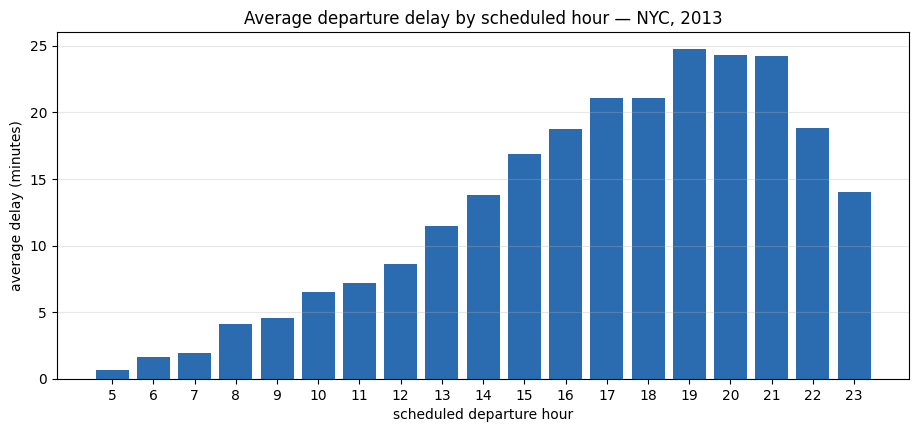

In [25]:
plt.figure(figsize=(11, 4.5))
plt.bar(by_hour["hour"], by_hour["avg_dep_delay"], color="#2b6cb0")
plt.title("Average departure delay by scheduled hour — NYC, 2013")
plt.xlabel("scheduled departure hour")
plt.ylabel("average delay (minutes)")
plt.xticks(by_hour["hour"])
plt.grid(axis="y", alpha=0.3)
plt.show()

### 🔧 YOUR TURN 4.3 — Put a number on it
That shape is worth money, but "the bars go up" is not a board recommendation.

Split the day into two shifts and compare them directly. Flights scheduled
**before 9am** versus flights scheduled **3pm or later**.

💡 **HINT:** `CASE WHEN` can create a label to group by:
```sql
SELECT CASE WHEN hour < 9 THEN 'morning' ELSE 'afternoon/evening' END AS shift,
       ...
GROUP BY shift
```

In [26]:
q("""
SELECT CASE WHEN hour < 9 THEN 'A morning (before 9am)'
            ELSE 'B afternoon/evening (3pm+)' END AS shift,
       COUNT(*) AS n,
       ROUND(AVG(dep_delay), 2) AS avg_dep_delay,
       ROUND(100.0 * SUM(CASE WHEN arr_delay > 15 THEN 1 ELSE 0 END)
             / COUNT(arr_delay), 1) AS pct_late
FROM flights
WHERE hour IS NOT NULL AND (hour < 9 OR hour >= 15)
GROUP BY shift
""")

,shift,n,avg_dep_delay,pct_late
0,A morning (before 9am),77968,2.57,12.8
1,B afternoon/evening (3pm+),145912,21.08,32.3


🧠 **ANALYST'S MEMO — the mechanism**

The 6am flights leave essentially on time. The 7pm flights leave more than twenty
minutes late on average. Same airlines. Same airports. Same runways.

Weather can't explain it — it isn't systematically stormier at 7pm than at 6am
across an entire year.

*So what is actually happening? Think about the physical aircraft. It flew this
morning too. And this afternoon. And it's the same plane.*

*Write the mechanism in two or three sentences.*

**YOUR ANSWER:**

---

**This is your finding.** Every airline in New York had this data. Northstar is
about to schedule around it.

### 🔧 YOUR TURN 4.4 — Does it hold everywhere?
Before you bet the company on it, check that the pattern isn't an artifact of one
airport or one airline.

Show average delay by hour **for each origin** — three columns of evidence
instead of one.

💡 **HINT:** you can group by two things at once: `GROUP BY origin, hour`.

In [ ]:
# YOUR CODE HERE
q("""
SELECT CAST(hour AS INTEGER) AS hour, origin,
       ROUND(AVG(dep_delay), 1) AS avg_dep_delay
FROM flights
WHERE hour IS NOT NULL AND dep_delay IS NOT NULL AND hour BETWEEN 6 AND 21
GROUP BY origin, hour
ORDER BY hour, origin
""")

---
# 🌧️ Mission 5 · Marcus's Weather Defence
⏱️ 15 minutes

---
**FROM:** Marcus Bell, VP Operations
**SUBJECT:** RE: your "breakthrough"
**PRIORITY:** ANNOYED

> I've been running airline ops for nineteen years. Delays are **weather**. It's
> New York. Fog, thunderstorms, snow. Your little bar chart is cute but you're
> describing weather and calling it scheduling.
>
> Prove me wrong. I'll wait.
---

Marcus is not being unreasonable. He might be right. Go and check — properly.

### The hardest JOIN in this project
The `weather` table has one row per **airport per hour**: `origin`, `year`,
`month`, `day`, `hour`.

To attach the weather to a flight, one matching column isn't enough — the same
`hour = 14` happens 365 days a year at 3 airports. You need **all five columns to
match at once**, chained with `AND`:

```sql
FROM flights f
JOIN weather w
  ON f.origin = w.origin
 AND f.year   = w.year
 AND f.month  = w.month
 AND f.day    = w.day
 AND f.hour   = w.hour
```

(`f` and `w` are nicknames — **aliases** — so you don't have to type the full
table name every time.)

This one takes a few seconds to run. It's comparing hundreds of thousands of rows.

### 🔧 YOUR TURN 5.1 — Delay vs visibility
`visib` is visibility in miles — 10 is a clear day, 0 is fog you can't see
through. Join the tables and get the average departure delay for each visibility
value.

In [ ]:
q("""
SELECT ROUND(w.visib) AS visibility_miles,
       COUNT(*) AS n_flights,
       ROUND(AVG(f.dep_delay), 1) AS avg_dep_delay
FROM flights f
JOIN weather w
  ON ...
GROUP BY visibility_miles
ORDER BY visibility_miles
""")

### 😬 Marcus was right. Partly.
Look at that table. On a fogged-in day, delays roughly **double or triple**.
Weather absolutely wrecks an operation.

But look at the `n_flights` column too. Then run the next task.

### ⚠️ TRAP 5.2 — The question Marcus didn't ask
**How often is the weather actually bad?**

Compute the percentage of NYC hours in 2013 with visibility below 10 miles.

💡 **HINT:** `CASE WHEN visib < 10 THEN 1 ELSE 0 END` over the `weather` table.

In [ ]:
q("""
...
FROM weather
""")

🧠 **ANALYST'S MEMO — how to win the argument**

Here is the shape of your reply to Marcus, and it's a genuinely subtle piece of
reasoning:

- Bad weather has a **big effect** — it can triple a delay.
- Bad weather is **uncommon** — a small share of the year.
- Therefore bad weather can **spoil specific days**, but it cannot be what's
  driving the ordinary, everyday, all-year-round pattern you found in Mission 4.

**Big effect × rare event = small contribution to the average.**

*Write Marcus a reply. Be respectful — he's been right about a lot of things for
nineteen years, and he's partly right here. Concede what he's right about, then
show him your numbers. Use both percentages.*

**YOUR ANSWER:**

### 🏆 BOSS — Settle it properly
There's a way to check both explanations at once: look at delay by hour **using
only clear-weather flights**. If the morning-to-evening ramp survives with the
weather removed, Marcus's explanation is finished.

Add `WHERE w.visib >= 10` to a joined query grouped by hour, and compare it
against your Mission 4.1 table.

💡 **HINT:** ⚠️ *both* tables have a column called `hour`, so SQLite will refuse
to guess which one you mean. Name your result something else —
`CAST(f.hour AS INTEGER) AS dep_hour` — and group by `dep_hour`.

In [ ]:
# YOUR CODE HERE


---
# 🏆 The Board Deck
⏱️ 10 minutes

---
**FROM:** Dana Reyes, CEO
**SUBJECT:** Board meeting, 9am

> Everything you've found, on one page. The board reads three bullets and one
> recommendation. That's it. That's the whole attention span.
>
> Every claim needs a number attached or I'm not saying it out loud.
---

### 🔧 FINAL QUERY — the launch schedule
One last piece of evidence: **the single best hour to fly from each airport.**

This needs a **window function** — a tool for ranking rows *within* groups:

```sql
SELECT origin, hour, avg_delay FROM (
    SELECT origin,
           CAST(hour AS INTEGER) AS hour,
           ROUND(AVG(dep_delay), 2) AS avg_delay,
           RANK() OVER (PARTITION BY origin ORDER BY AVG(dep_delay)) AS r
    FROM flights
    WHERE hour IS NOT NULL AND dep_delay IS NOT NULL AND hour BETWEEN 6 AND 21
    GROUP BY origin, hour
)
WHERE r = 1
```

Read the inner query slowly. `PARTITION BY origin` means *restart the ranking for
each airport*. The outer query keeps only the winners.

Run it. Then **change it** to give the best **three** hours at each airport —
that's Northstar's actual departure bank.

In [ ]:
# YOUR CODE HERE


---
## 📄 NORTHSTAR AIRWAYS — BOARD RECOMMENDATION
### Prepared by: **(your name)**

**Finding 1 — Home airport.**
*(which airport, and the number that proves it)*

**Finding 2 — Schedule.**
*(the hour-of-day pattern, with two numbers: morning vs evening)*

**Finding 3 — Weather.**
*(what weather does and doesn't explain, with both percentages)*

**RECOMMENDATION:**
*(One paragraph. Which airport, which departure hours, and what on-time
percentage Northstar can honestly promise passengers.)*

**WHAT WOULD CHANGE MY MIND:**
*(One thing you'd need to check before betting the company. Every real analysis
has one. Naming it is a strength, not a weakness.)*


---
# 🎖️ Certification Checklist

- [ ] I can list the tables in a database and read its schema
- [ ] I know why `COUNT(*)` and `COUNT(column)` give different answers
- [ ] I can use `CASE WHEN` to turn a condition into a percentage
- [ ] I know the difference between `WHERE` and `HAVING` and can explain it out loud
- [ ] I can `JOIN` two tables — including on five columns at once
- [ ] I have used a window function and can say what `PARTITION BY` does
- [ ] I found a confounding variable before it embarrassed me
- [ ] I made a recommendation with a number attached to every claim

### 🚀 Stretch missions

1. **The vanishing minutes.** In Mission 1 you noticed planes make up time in the
   air. Test your theory: group by short / medium / long flights using `CASE WHEN`
   on `distance`, and compute `AVG(dep_delay - arr_delay)`. Does the amount
   recovered grow with distance? What does that tell you about how airlines pad
   their schedules?

2. **The cursed aircraft.** Rank individual planes by `tailnum` with
   `HAVING COUNT(*) > 100`. One plane will look genuinely cursed. Before you
   ground it — check which airline flies it and out of which airport. Is it a bad
   plane, or a plane on a bad route? (You've seen this trick before.)

3. **When should we not fly at all?** Average delay by `month`. Two months are
   dramatically worse than the rest. Which, and what's your explanation? Then
   find the two best months.

4. **Route selection.** Which destinations have the *best* on-time record from
   your chosen airport, with at least 500 flights a year? That's Northstar's
   opening route map.

5. **The honest brochure.** Using only SQL, produce the single sentence
   Northstar's marketing team can legally put on the website about on-time
   performance — and be ready to defend every number in it.
